# GNN PROTAC splitter - Node classifier - Experimental Architectures

In [1]:
# Standard library imports
import os
import sys
import io

# Data handling and scientific computing
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.linalg import inv

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, NNConv
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

# RDKit for cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, GetPeriodicTable
from rdkit.Chem.Draw import rdMolDraw2D

# NetworkX for network analysis
import networkx as nx

# Matplotlib for plotting and visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Other utilities
from tqdm import tqdm
from PIL import Image

# External datasets
from datasets import load_dataset


import re


sys.path.append('./Code/TestingGround/src/models/')

/home/knkn308/.conda/envs/env-protac-toolkit/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# User inputs:
Note that new datasets (as in a new "dataname") have all descriptors calculated from scratch, which is then saved. If there exists a dataset with a given dataname, it is retrived instead.

In [2]:
Highlighted_graph_descriptors = ['betweenness', 'local_betweenness_5', 'local_eigenvectors_x', 'local_normAvgShortestPath_5', 'local_prod_betweenness_avgShortestPath_4']   ##Which graph descriptors to calculate for the data and use to train the GNN model. There exists more graph descriptors
Existing_datanames = ["AIBE_GraphDescriptors-b-lb-le-lasp-lpbasp", "AIBE_GraphDescriptors-b-lb-le-lasp-lpbasp_Set1RDKitfeatures", "PROTACsmiles_I_NoSymmetric"]
Existing_models = ["model_GraphDescriptors-b-lb-le-lasp-lpbasp_FullAibeDataset.pth", "model_NoGraphDescriptors_FullAibeDataset.pth", "GraphConv_2_3layers_AIBE_GraphDescriptors-b-lb-le-lasp-lpbasp_Set1RDKitfeatures"]
modes = ['plot', 'dont plot']



#user input
graph_descriptor_list = Highlighted_graph_descriptors
dataname = "GraphConv_2_3layers_AIBE_GraphDescriptors-b-lb-le-lasp-lpbasp_Set1RDKitfeatures_graphsWithPos" #Existing_datanames[0] # Which dataset to use
save_model = False
model_name = False #f"GraphConv_2_3layers_{dataname}" #either False or str. For loading existing models OR saving trained model
training_epochs = 15
mode = modes[1]   #['plot', 'dont plot']                       
num_plotted_protacs = 20 #


# Core functions 

## General functions

In [3]:
def substructure_split_sort(substructure_smiles):
    for smile in substructure_smiles:
        if '[*:1]' in smile:
            if '[*:2]' in smile:
                linker_smile = smile
            else:
                poi_smile = smile
        elif '[*:2]' in smile:
            e3_smile = smile
        else:
            raise ValueError(f'[*:1] and [*:2] was not found in smile: {smile}')
    return poi_smile, linker_smile, e3_smile


def EdgeLabler(protac_smiles, substructure_smiles, print_smiles=False):
    """
    Draws a molecule with highlighted bonds where the substructures attach to the rest of the molecule.
    Additionally, it outputs a NetworkX graph and the indices of the corresponding bonds.
    
    Parameters:
    protac_smiles (str): The SMILES string of the molecule.
    substruct_smiles (list): A list of SMILES strings of the substructures with dummy atoms.
    
    Returns:
    G (NetworkX graph): The graph representation of the molecule.
    edge_indices (list): The indices of the atoms forming the corresponding bonds in the graph.
    """
    
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)

    if print_smiles is True:
        print(f'PROTAC: {protac_smiles}')
        print(f'poi_smile: {poi_smile}')
        print(f'linker_smile: {linker_smile}')
        print(f'e3_smile: {e3_smile}')
    
    mol = Chem.MolFromSmiles(protac_smiles)
    G = nx.Graph()
    edge_indices = []

    # Add edges from the molecule to the graph
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # Process the two largest substructures
    substructure_smiles_temp = [smile for smile in substructure_smiles]     #duplicate list as to not delete it in "substructure_smiles"
    index_of_shortest = min(range(len(substructure_smiles_temp)), key=lambda i: len(substructure_smiles_temp[i]))
    del substructure_smiles_temp[index_of_shortest] # Remove the smallest smiles

    for substruct_smiles in substructure_smiles_temp:
        substruct_mol = Chem.MolFromSmiles(substruct_smiles)
        matches = mol.GetSubstructMatches(Chem.DeleteSubstructs(substruct_mol, Chem.MolFromSmiles('*')))

        if not matches:
            continue  # If no match is found, skip to the next substructure
        match = matches[0]  # Take the first match                                         ##########################OBS!

        # Find the corresponding bond
        for bond in mol.GetBonds():
            begin_atom_label = int(bond.GetBeginAtomIdx() in match)
            end_atom_label = int(bond.GetEndAtomIdx() in match)
            if begin_atom_label != end_atom_label:
                edge_indices.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))

    sorted_edge_indices = [tuple(sorted(t)) for t in edge_indices]    #Create an unique set of edges
    unique_edge_set = set(sorted_edge_indices) # Step 2: Convert the list of sorted tuples to a set to remove duplicates
    unique_edge_indices = list(unique_edge_set) # Step 3: Convert the set back to a list

    if not edge_indices:
        print("No corresponding bonds were found.")
        return G, None

    return G, unique_edge_indices

def normalize(vector, vector_max=None, vector_min=None):
    if vector_max is None:
        vector_max = vector.max()
    if vector_min is None:
        vector_min = vector.min()
    vector_norm = (vector-vector_min)/(vector_max-vector_min)
    return vector_norm

# Function to create the line graph G_e from graph G
def line_graph_custom(G):                                             #use nx.line_graph instead?
    # Initialize the line graph G_e
    G_e = nx.Graph()

    # Create a mapping of edges to nodes for G_e
    edge_to_node = {edge: idx for idx, edge in enumerate(G.edges())}

    # Add nodes to G_e, each node represents an edge in G
    for edge, node in edge_to_node.items():
        G_e.add_node(node, edge=edge)

    # Iterate through each edge in G and connect the corresponding nodes in G_e
    for edge in G.edges():
        # Find the node in G_e that represents this edge
        node_for_edge = edge_to_node[edge]
        # Find adjacent edges in G, and create edges between nodes in G_e
        for adj_edge in G.edges(edge[0]):
            if adj_edge != edge:
                # Ensure that we have the edge in the right order for lookup
                adj_edge = tuple(sorted(adj_edge))
                adj_node = edge_to_node[adj_edge]
                G_e.add_edge(node_for_edge, adj_node)
        for adj_edge in G.edges(edge[1]):
            if adj_edge != edge:
                # Ensure that we have the edge in the right order for lookup
                adj_edge = tuple(sorted(adj_edge))
                adj_node = edge_to_node[adj_edge]
                G_e.add_edge(node_for_edge, adj_node)

    G_e.remove_edges_from(nx.selfloop_edges(G_e))
    return G_e

def assign_pos_to_graph(smile, G):
    mol = Chem.MolFromSmiles(smile)
    AllChem.Compute2DCoords(mol)
    # Assign 2D coordinates to nodes
    conf = mol.GetConformer()
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        G.nodes[atom.GetIdx()]['pos'] = (pos.x, pos.y)
    pos = nx.get_node_attributes(G, 'pos')
    return G, pos


#def identify_correct_substructure_match()

## Graph descriptor functions

More graph descriptors:
https://en.wikipedia.org/wiki/Centrality: Percolation centrality, Harmonic centrality, Freeman centralization, Dissimilarity-based centrality measures



Established node descriptors: bonacich_custom, betweenness_custom, eigenvector_custom, katz_custom      
Personal node descriptors: ovality, eccentricity, major_minor_axis_ratio, general_wiener_vector

Global -> Node pair: general_wiener_matrix, general_modified_wiener_matrix 

Global descriptors: wiener_index, hyper_wiener_index, general_modified_wiener_index, average_shortest_path_custom

### Node Descriptors

In [4]:
#Established descriptors

def bonacich_custom(G, beta=0.1):
    adj_matrix = nx.adjacency_matrix(G).toarray()
    n = adj_matrix.shape[0]
    x = np.ones((n, 1))
    bonacich_values = np.linalg.inv(np.eye(n) - beta * adj_matrix.T) @ (x) # C = (I−βA)^−1 * I
    bonacich_values = bonacich_values.flatten()
    return bonacich_values

def betweenness_custom(G):
    betweenness = nx.betweenness_centrality(G)
    return betweenness

def eigenvector_custom(G):
    eigenvector = nx.eigenvector_centrality(G, max_iter=100000)
    return eigenvector

def katz_custom(G):
    eigenvector = nx.eigenvector_centrality(G, max_iter=100000)
    eigenvector_values = np.array([eigenvector[node] for node in G.nodes()])
    max_eigenvector = eigenvector_values.max()
    alpha = 1/(9*max_eigenvector) # α is a constant that determines the attenuation factor for distant nodes. It should be set so that it's smaller than the reciprocal of the largest eigenvalue of the adjacency matrix for the centrality scores to be meaningful.
    beta  = 0.1
    adj_matrix = nx.adjacency_matrix(G)
    I = np.identity(adj_matrix.shape[0])
    katz = np.dot(inv(I - alpha * adj_matrix), beta * np.ones(adj_matrix.shape[0]))   #Works better than nx.katz_centrality(G, alpha=0.9, beta=1), np.array([katz[node] for node in G.nodes()]), as this may fail to converge
    return katz



# ----------------------------------------------


# Global -> node pair descriptors

#wiener_matrix gives a value for each pair of nodes
def general_wiener_matrix(G):
    nodes = list(G.nodes())
    wiener_matrix = np.zeros((len(nodes), len(nodes)))
    for i, node_i in enumerate(nodes):
        for j, node_j in enumerate(nodes):
            if i != j:
                wiener_matrix[i, j] = nx.shortest_path_length(G, node_i, node_j)
    return wiener_matrix

def general_modified_wiener_matrix(G):      
    wiener_matrix = general_wiener_matrix(G)
    modified_wiener_matrix = np.where(wiener_matrix != 0, 1 / wiener_matrix, 0) # Construct modified Wiener matrix by taking the reciprocal of the non-diagonal elements
    np.fill_diagonal(modified_wiener_matrix, 0)  # Ensure the diagonal is zero
    return modified_wiener_matrix


# ----------------------------------------------



# Personal descriptors

def ovality(G):
    num_nodes = G.number_of_nodes()  # Count the number of nodes
    diameter = nx.diameter(G)       # Get the diameter of the graph
    minor_axis_length = num_nodes/diameter
    return minor_axis_length

def eccentricity(G):
    num_nodes = G.number_of_nodes()  # Count the number of nodes
    diameter = nx.diameter(G)       # Get the diameter of the graph
    eccent = (1-num_nodes/(diameter**2))**0.5
    return eccent

def major_minor_axis_ratio(G):
    num_nodes = G.number_of_nodes()  # Count the number of nodes
    diameter = nx.diameter(G)       # Get the diameter of the graph
    major_minor_axis_ratio = num_nodes/(diameter**2)
    return major_minor_axis_ratio

def general_wiener_vector(G):                                                #Doesn seem informative
    return general_wiener_matrix(G).sum(axis=0)

### Gobal Descriptors
Can be transformed to node descriptors via SubGraphLoop

In [5]:
def wiener_index(G):
    path_length_dict = dict(nx.all_pairs_shortest_path_length(G))
    wiener_index = sum(sum(d for d in length.values()) for length in path_length_dict.values()) / 2
    return wiener_index

def hyper_wiener_index(G):
    path_length_dict = dict(nx.all_pairs_shortest_path_length(G))
    hyper_wiener_index = sum(sum(d + d**2 for d in length.values()) for length in path_length_dict.values()) / 2
    return hyper_wiener_index

def general_modified_wiener_index(G): # Function to calculate modified Wiener index for general graphs
    modified_wiener_matrix = general_modified_wiener_matrix(G)
    modified_wiener_index = np.sum(modified_wiener_matrix) / 2 # Modified Wiener index is the sum of all elements since matrix is already reciprocal for non-diagonal elements
    return modified_wiener_index

def average_shortest_path_custom(G):
    avg = nx.average_shortest_path_length(G)
    num_nodes_subgraph = G.number_of_nodes()
    normalized_avg = avg/num_nodes_subgraph
    return normalized_avg

### Core graph functions

In [6]:
def subgraphLoop(G, radius_scan=None, rad_diam_proportion=2.5, custom_function=None, powerPreNorm=1, powerPostNorm=1, transformation=None):
    diameter = nx.diameter(G)   #Automatic and custom radius of the subgraphs that will be generated
    if radius_scan is None:
        radius_scan = diameter // rad_diam_proportion   #Automatically calc radius of subgraph based on diameter
            
    node_dict = {}              #Initialize a dictionary
    for node_index in G.nodes():
        node_dict[node_index] = 0
            
    for node_index in G.nodes():                                 #Loop over all nodes & create subgraphs
        subgraph = nx.ego_graph(G, node_index, radius=radius_scan) #Create subgraph at node, with radius r
                
        #Calculations
        output_custom_function = custom_function(subgraph) #All custom functions must only take 1 nx.graph as input
                
                #Assign values corresponding to the node(s) in the complete graph from the calculations
        if isinstance(output_custom_function, (int, float)):                    # Global metric will return 1 value
            node_dict[node_index]=custom_function(subgraph)                  #Apply custom function to subgraph, and store with the node index which the graph is centered at
        else:                                                                #Local metric. Transfer it from all nodes in subgraph to complete graph
            for subgraph_node_index in subgraph.nodes():
                node_dict[subgraph_node_index] += output_custom_function[subgraph_node_index]#output_custom_function.get(subgraph_node_index, 0) #The output is from a networkx function.  # Default to 0 if not found

    #Data processing
    Array = np.array([value for _, value in node_dict.items()])
    if transformation is not None:
        Array = transformation(Array)
    Array = np.power(Array, powerPreNorm)
    Array_norm = normalize(Array)
    Array_norm = np.power(Array_norm, powerPostNorm)
    return Array_norm


def graph_descriptor(G, descriptor=None):
    if descriptor == 'degree':
        degrees = np.array([d for n, d in G.degree()])
        calc_values = normalize(vector=degrees, vector_max=4, vector_min=1)
    elif descriptor == 'betweenness':
        betweenness = nx.betweenness_centrality(G)
        calc_values = np.array([betweenness[node] for node in G.nodes()])
    elif descriptor == 'eigenvector':
        eigenvector = nx.eigenvector_centrality(G, max_iter=100000)
        calc_values = np.array([eigenvector[node] for node in G.nodes()])
    elif descriptor == 'closeness':
        closeness = nx.closeness_centrality(G)
        calc_values = np.array([closeness[node] for node in G.nodes()])
    elif descriptor == 'bonacich':
        calc_values = bonacich_custom(G)
    elif descriptor == 'katz':
        calc_values = katz_custom(G)
    elif descriptor == 'local_eigenvectors_x':
        calc_values = subgraphLoop(G, custom_function=eigenvector_custom, powerPreNorm=0.1)
    elif descriptor == 'local_betweenness_5':
        calc_values = subgraphLoop(G, custom_function=betweenness_custom, radius_scan=5) 
    elif descriptor == 'local_normAvgShortestPath_5':
        calc_values = subgraphLoop(G, custom_function=average_shortest_path_custom, radius_scan=5)    
    elif descriptor == 'local_prod_betweenness_avgShortestPath_4':
        betweenness = nx.betweenness_centrality(G)
        betweenness_values = np.array([betweenness[node] for node in G.nodes()])
        avg_values = subgraphLoop(G, custom_function=average_shortest_path_custom, radius_scan=4, powerPostNorm=1/3)
        calc_values = normalize(betweenness_values*avg_values)
    else:
        raise ValueError(f'Give a valid descriptor:"{descriptor}"')
    calc_values = normalize(calc_values)
    return calc_values

# PROTACDataset - WIP The dataset class needs to be able to import CSVs

## Dataset processing functions - WIP Multiple substructure matches

In [7]:
def remove_dummy_atoms(mol):
    atoms_to_remove = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() == 0]
    editable_mol = Chem.EditableMol(mol)
    for idx in sorted(atoms_to_remove, reverse=True):
        editable_mol.RemoveAtom(idx)
    return editable_mol.GetMol()

def identify_substructure_indices(protac_mol, poi_mol, e3_mol, protac_smile): #:return: List of atom indices that match the substructure .
    matches_poi = protac_mol.GetSubstructMatches(poi_mol)
    matches_e3 = protac_mol.GetSubstructMatches(e3_mol)

    if len(matches_poi) == 1 and len(matches_e3) == 1:
        poi_indices = [atom_idx for atom_idx in matches_poi[0]] 
        e3_indices = [atom_idx for atom_idx in matches_e3[0]]
    elif len(matches_poi) == 2 and len(matches_e3) == 2:                                                                                                        ##########################OBS Work in progress
        #assume POI = E3 

        #case 1: equal attatchment points to linker

        #case 2: unequal attachment points to linker

        e3_mol_no_attatchment_point = remove_dummy_atoms(e3_mol)
        poi_mol_no_attatchment_point = remove_dummy_atoms(poi_mol)
        poi_linker = Chem.DeleteSubstructs(protac_mol, e3_mol_no_attatchment_point)
        e3_linker = Chem.DeleteSubstructs(protac_mol, poi_mol_no_attatchment_point)

        matches_poi_linker = protac_mol.GetSubstructMatches(poi_linker)
        matches_e3_linker = protac_mol.GetSubstructMatches(e3_linker)

        #linker_indicies_from_intersection = list(set(matches_poi_linker).intersection(matches_e3_linker))

        
        poi_indices = matches_poi_linker
        #poi_indices.remove(linker_indicies_from_intersection)
        e3_indices = matches_e3_linker
        #e3_indices.remove(linker_indicies_from_intersection)
        #print(protac_smile)
        raise ValueError(f'2 substructure matches for protac: {protac_smile}')

    else:
        #print(protac_smile)
        raise ValueError(f'Complex substructure match for protac: {protac_smile}')


    # Calculate Linker indices by excluding POI and E3 indices
    all_indices = set(range(protac_mol.GetNumAtoms()))
    linker_indices = all_indices - set(poi_indices) - set(e3_indices)

    return list(set(poi_indices)), list(set(linker_indices)), list(set(e3_indices))   # Flatten the tuple of matches and return unique indices 

def create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile):
    """
    Creates a mapping of atom indices from the original PROTAC molecule to their
    corresponding substructures (POI, E3, and Linker).
    :return: Dictionary with keys 'POI', 'E3', and 'Linker', each containing a list of atom indices.
    """
    protac_mol = Chem.MolFromSmiles(protac_smile)
    poi_mol = remove_dummy_atoms(Chem.MolFromSmiles(poi_smile))
    e3_mol = remove_dummy_atoms(Chem.MolFromSmiles(e3_smile))

    poi_indices, linker_indices, e3_indices = identify_substructure_indices(protac_mol, poi_mol, e3_mol, protac_smile)

    # Create the mapping
    substructure_mapping = {
        'POI': list(poi_indices),
        'Linker': list(linker_indices),
        'E3': list(e3_indices)}
    
    return substructure_mapping

def one_hot_encode_substructure_labels(protac_smile, poi_smile, e3_smile):
    substructure_mapping = create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile) # Get dictionary of which atom ids belong to which substructure
    num_nodes = len(substructure_mapping['POI']) + len(substructure_mapping['Linker']) + len(substructure_mapping['E3'])
    one_hot_encoded = np.zeros((num_nodes, 3), dtype=int) # Initialize an array of zeros
    
    # Update the array based on the substructure mapping
    for col_idx, key in enumerate(['POI', 'Linker', 'E3']):
        indices = substructure_mapping[key]
        one_hot_encoded[indices, col_idx] = 1

    return one_hot_encoded

# Function to convert a molecule to a graph
def mol_to_graph(mol, transform=False):
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(),                                  
                   atomic_num=atom.GetAtomicNum(),
                   degree=atom.GetDegree(),
                   formal_charge=atom.GetFormalCharge(),
                   aromatic=atom.GetIsAromatic()
                   )
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
                   bond_type=bond.GetBondType(),
                   is_conjugated=bond.GetIsConjugated(),
                   in_ring=bond.IsInRing())                         ##If adding edge features here, also, expand smiles_to_data to unpack these from the graph.

    #All nodes and edges must be defined before graph descriptors can be calculated. Start calculating them here:
    graph_descriptors = graph_descriptor_list
    for descriptor_str in (graph_descriptors):
        graph_descriptor_dict = {}
        descriptor_value = graph_descriptor(G, descriptor=descriptor_str)
        for node in G.nodes():
            graph_descriptor_dict[node] = descriptor_value[node]
        nx.set_node_attributes(G, graph_descriptor_dict, descriptor_str)

    if transform is True:
        #Implement the line_graph function here. Think about downstream
        pass
    
    Graph = G
    return Graph

def graph_to_mol(G):
    # Create an empty editable molecule
    new_mol = Chem.RWMol()

    # Add atoms to the molecule
    for node, attr in G.nodes(data=True):
        atom = Chem.Atom(attr['atomic_num'])
        atom.SetFormalCharge(attr['formal_charge'])
        atom.SetIsAromatic(attr['aromatic'])
        new_mol.AddAtom(atom)

    # Add bonds to the molecule
    for start, end, attr in G.edges(data=True):
        bond_type = attr['bond_type']
        new_mol.AddBond(start, end, bond_type)

    # Convert to a standard RDKit molecule and return
    mol = new_mol.GetMol()
    Chem.SanitizeMol(mol)
    return mol


def smiles_to_data(protac_smile, substructure_smiles):
    mol = Chem.MolFromSmiles(protac_smile)
    G = mol_to_graph(mol)

    # Extract node features
    node_feature_list = [list(G.nodes[node].values()) for node in G.nodes]
    node_features = torch.tensor(node_feature_list, dtype=torch.float)

    _, boundary_edges = EdgeLabler(protac_smile, substructure_smiles)
    #boundary_edges_set = set(boundary_edges)

    # Extract edge indices and features
    edge_indices = []
    edge_labels = []
    edge_features = []
    for edge in G.edges(data=True):
        start, end = edge[0], edge[1]

        if (start, end) in boundary_edges:
            edge_labels.append(1)
        elif (end, start) in boundary_edges:
            edge_labels.append(1)
        else: 
            edge_labels.append(0)
        
        edge_indices.append((start, end))
        edge_indices.append((end, start))  # since it's an undirected graph
                        
        # Bond type one-hot encoding
        edge_feature_dict = edge[2]
        
        edge_feature = [
            int(edge_feature_dict['bond_type'] == Chem.rdchem.BondType.SINGLE),
            int(edge_feature_dict['bond_type'] == Chem.rdchem.BondType.DOUBLE),
            int(edge_feature_dict['bond_type'] == Chem.rdchem.BondType.TRIPLE),
            int(edge_feature_dict['bond_type'] == Chem.rdchem.BondType.AROMATIC),
            int(edge_feature_dict['is_conjugated']),
            int(edge_feature_dict['in_ring'])
            ]
        edge_features.extend([edge_feature, edge_feature])  # add twice for both directions

    edge_indices = torch.tensor(edge_indices).t().contiguous()
    edge_features = torch.tensor(edge_features, dtype=torch.float)
    edge_labels = torch.tensor(edge_labels, dtype=torch.float)  

    poi_smile, _, e3_smile = substructure_split_sort(substructure_smiles)
    node_substructure_label_np = one_hot_encode_substructure_labels(protac_smile, poi_smile, e3_smile) #Direct node classification of all atoms of which substructure it belongs to    
    node_substructure_label = torch.from_numpy(node_substructure_label_np)

    assign_pos_to_graph(protac_smile, G)

    data = Data(x=node_features, 
                edge_attr=edge_features,
                edge_labels=edge_labels,
                edge_index=edge_indices,
                node_substructure_label=node_substructure_label, 
                smiles=protac_smile,
                substructure_smiles=substructure_smiles,      
                G=G
                ) 
    return data

In [8]:
                                                                                 ##########################OBS Work in progress
class PROTACDataset(Dataset):
    # Change: Added `data` parameter to accept a DataFrame directly
    # TODO: Include auto labeling of graph for a PROTAC by its substructures. Then in an indexed list of all nodes, [num_nodes, 3], do a 1-hot encoding as a y value.
    # Evaluate using maximum common substructure divided by the number of atoms in the substructure (or total unique atoms in known and predicted substructure). If the predicted fragment consists of isolated nodes, solve by selecting the largest set of connected nodes as the ONLY part to evaluate (big punishment for unconnected or missing nodes)

    def __init__(self, filename=None, data=None, substructures=None, name='default_name', root=None, transform=None, pre_transform=None):
        """
        Initialize the dataset with either a filename or a DataFrame.
        root = Where the dataset should be stored. This folder is split
        into raw_dir (downloaded dataset) and processed_dir (processed data).
        """
        # Change: Initialize filename to None
        self.substructures = substructures
        self.data = data
        self.filename = filename
        if isinstance(filename, str) and filename.endswith(".csv") and name == 'default_name':
            self.name = filename[:-4]
        elif name != 'default_name':
            self.name = name

        if root is None:  # Root is data directory by default
            current_directory = os.getcwd()
            root = os.path.join(current_directory, "..", "..", "data")

        # Change: Initialize the parent class at the end of the constructor
        super(PROTACDataset, self).__init__(root, transform, pre_transform)

    @property
    def raw_file_names(self):
        """ If this file exists in raw_dir, the download is not triggered. """
        # Change: Check if self.filename is not None before returning
        if self.filename:
            return self.filename
        else:
            # Change: Return an empty list if no filename is provided
            return []

    @property
    def processed_file_names(self):
        """ If these files are found in processed_dir, processing is skipped """
        # Change: Check if data is already loaded before trying to read CSV
        if self.data is not None:
            self.data = self.data.reset_index(drop=True)
        else:
            # Change: Only read CSV if filename is provided
            if self.filename:
                self.data = pd.read_csv(self.raw_paths[0]).reset_index(drop=True)
        # Change: Generate file names based on the length of self.data
        return [f'data_{self.name}_{i}.pt' for i in range(len(self.data))]

    def download(self):
        # Change: Download method can remain empty or handle downloading if necessary
        pass

    def process(self):
        # Change: Check if self.data is a DataFrame and process it
        if isinstance(self.data, pd.DataFrame):
            if self.substructures is None:
                raise ValueError(f'If you give a dataframe of SMILES for the PROTACs, you must also give the SMILES for their substructures to get boundary edges!')
            
            for index, row in tqdm(self.data.iterrows(), total=self.data.shape[0]):
                data = smiles_to_data(protac_smile=row["smiles"], 
                                      substructure_smiles=self.substructures['substructures'][index].split("."))
                torch.save(data, os.path.join(self.processed_dir, f'data_{self.name}_{index}.pt'))
        else:
            # Handle case where self.data is not a DataFrame, e.g., a string of the name for a csv file!
           raise ValueError(f'Not implemented yet that you can use a CSV file')

    def len(self):
        # Change: Return the length of self.data
        return len(self.data)

    def get(self, idx):
        # Change: Simplified get method without graph and mol parameters
        data = torch.load(os.path.join(self.processed_dir, f'data_{self.name}_{idx}.pt'))
        return data

## Download data

In [9]:
name_dataset_aibe = "80-20-split"
dataset_aibe = load_dataset("ailab-bio/PROTAC-Substructures", name_dataset_aibe) #download
train_dataset = dataset_aibe['train']
validation_dataset = dataset_aibe['validation']

train_texts = train_dataset['text']
train_labels = train_dataset['labels']

validation_texts = validation_dataset['text']
validation_labels = validation_dataset['labels']


## Load data & (temporarily) remove symmetric protacs

In [10]:
#Load data

PROTACsmiles_df_training = pd.DataFrame(train_texts, columns=['smiles'])
Substructuressmiles_df_training = pd.DataFrame(train_labels, columns=['substructures'])
PROTACsmiles_df_validation = pd.DataFrame(validation_texts, columns=['smiles'])
Substructuressmiles_df_validation = pd.DataFrame(validation_labels, columns=['substructures'])


remove_symmetric_protacs = True
if remove_symmetric_protacs is True: 
    row_ids_to_remove = []
    symmetric_protacs_train = ['O=C1CCC(N2C(=O)c3cccc(NCCOCCOCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1',
                        'O=C1CCC(N2C(=O)c3cccc(NCCCOCCOCCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1',
                        'O=C1CCC(N2C(=O)c3cccc(NCCCOCCCCOCCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1',
                        'O=C1CCC(N2C(=O)c3cccc(NCCCOCCOCCOCCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1',
                        'O=C1CCC(N2C(=O)c3cccc(NCCOCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1',
                        'O=C1CCC(N2C(=O)c3cccc(OCCOCCOCCOc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1',
                        'O=C1CCC(N2C(=O)c3ccc(C(=O)NCCOCCOCCNC(=O)c4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)cc3C2=O)C(=O)N1',
                        'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCC(=O)NC(C(=O)N2CC(O)CC2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)C(C)(C)C)cc1',
                        'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOCC(=O)NC(C(=O)N2CC(O)CC2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)C(C)(C)C)cc1',
                        'CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1OCCOCCOCCOCCOCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)C(NC(C)=O)C(C)(C)C)C(C)(C)C',
                        'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1',
                        'CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1OCCOCCOCCOCCOCCOCC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C)C(C)(C)C'
                        ]
    symmetric_protacs_validation = ['Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCCOCCOCC(=O)NC(C(=O)N2CC(O)CC2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)C(C)(C)C)cc1']
    
    
    row_ids_to_remove_train = PROTACsmiles_df_training[PROTACsmiles_df_training['smiles'].isin(symmetric_protacs_train)].index
    row_ids_to_remove_validation = PROTACsmiles_df_validation[PROTACsmiles_df_validation['smiles'].isin(symmetric_protacs_validation)].index

    print("Length training dataset before removal:", len(PROTACsmiles_df_training), ' and ', len(Substructuressmiles_df_training))

    # Drop the rows from both dataframes
    PROTACsmiles_df_training.drop(row_ids_to_remove_train, inplace=True)
    Substructuressmiles_df_training.drop(row_ids_to_remove_train, inplace=True)

    print("Length training dataset after removal:", len(PROTACsmiles_df_training), ' and ', len(Substructuressmiles_df_training))

    print("Length validation dataset before removal:", len(PROTACsmiles_df_validation), ' and ', len(Substructuressmiles_df_validation))

    # Drop the rows from both dataframes
    PROTACsmiles_df_validation.drop(row_ids_to_remove_validation, inplace=True)
    Substructuressmiles_df_validation.drop(row_ids_to_remove_validation, inplace=True)

    print("Length validation dataset after removal:", len(PROTACsmiles_df_validation), ' and ', len(Substructuressmiles_df_validation))

    # Reset index if needed
    PROTACsmiles_df_training.reset_index(drop=True, inplace=True)
    Substructuressmiles_df_training.reset_index(drop=True, inplace=True)
    PROTACsmiles_df_validation.reset_index(drop=True, inplace=True)
    Substructuressmiles_df_validation.reset_index(drop=True, inplace=True)

training_dataset = PROTACDataset(data=PROTACsmiles_df_training, substructures=Substructuressmiles_df_training, name=f'{dataname}_train')
validation_dataset = PROTACDataset(data=PROTACsmiles_df_validation, substructures=Substructuressmiles_df_validation, name=f'{dataname}_val')


Length training dataset before removal: 1476  and  1476
Length training dataset after removal: 1464  and  1464
Length validation dataset before removal: 337  and  337
Length validation dataset after removal: 336  and  336


# Model

## Model functions

In [11]:

def val_test_split(validation_dataset, relative_test_size=0.3):

    val_size = len(validation_dataset)
    test_size = int(relative_test_size * val_size)
    val_size_new = val_size - test_size
    val_dataset_subset, test_dataset_subset  = random_split(validation_dataset, [val_size_new, test_size], generator=torch.Generator().manual_seed(42))
    
    val_dataset = [val_dataset_subset[i] for i in range(val_size_new)]
    test_dataset = [test_dataset_subset[i] for i in range(test_size)]
    return val_dataset, test_dataset

## GNN

In [12]:
from torch_geometric.nn import GraphConv

#GCNConv worked well before, with a test accuracy of around 0.93
#GraphConv: maybe converges faster?

class NodeClassifierGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim):
        super(NodeClassifierGNN, self).__init__()
        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)
        self.conv2 = GraphConv(64, 32)# edge_dim=edge_feature_dim)
        self.conv3 = GraphConv(32, 64)
        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes

    def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Output Layer
        y = self.out(z)
        return y

# Training function
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        
        optimizer.zero_grad()
        out = model(node_attr=data.x, edge_index=data.edge_index)#, edge_attr=data.edge_attr)

        # Convert one-hot encoded vectors to class indices
        target = data.node_substructure_label.argmax(dim=1)

        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)# , edge_attr=data.edge_attr)
            pred = out.argmax(dim=1)

            # Convert one-hot encoded vectors to class indices for comparison
            target = data.node_substructure_label.argmax(dim=1)
            
            correct += pred.eq(target).sum().item()
            total += data.node_substructure_label.size(0)
    return correct / total

def predict(model, data):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        out = model(data.x, data.edge_index) #, edge_attr=data.edge_attr)
        probabilities = F.softmax(out, dim=1)
        class_predictions = probabilities.argmax(dim=1)
    return class_predictions, probabilities

train_dataset = training_dataset
val_dataset = validation_dataset #, test_dataset = val_test_split(validation_dataset, relative_test_size=0.3)  #val_dataset_old, test_dataset_old = train_test_split(validation_dataset, test_size=0.3, random_state=42) 


# Create DataLoaders for batch processing (adjust batch_size as needed)
batch_size = 1                                                   #Larger batchsize gave worse result. Try again. Because of edge indexes?
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
#test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Model instantiation
if model_name and os.path.isfile(model_name):
    model = torch.load(model_name)
else:
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features 
    model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss() # Note: CrossEntropyLoss in PyTorch expects raw scores (logits) and class indices, not one-hot encoded labels If your labels are one-hot encoded, you might need to convert them to class indices


# Training and evaluation loop
for epoch in range(training_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_accuracy = evaluate(model, val_loader)
    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

# Test evaluation
#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

Epoch 1: Loss: 0.5683301138014741, Val Accuracy: 0.7685241619503701
Epoch 2: Loss: 0.4181035554056855, Val Accuracy: 0.8390944710491947
Epoch 3: Loss: 0.3559972326744531, Val Accuracy: 0.8619939050936003
Epoch 4: Loss: 0.31814597141191037, Val Accuracy: 0.8900304745319982
Epoch 5: Loss: 0.2913829299641641, Val Accuracy: 0.8985633434915107
Epoch 6: Loss: 0.2745141483120661, Val Accuracy: 0.8840661732694819
Epoch 7: Loss: 0.25924330960725095, Val Accuracy: 0.9033957335655203
Epoch 8: Loss: 0.24925836116136585, Val Accuracy: 0.9044841097083152
Epoch 9: Loss: 0.2415578487593823, Val Accuracy: 0.9049194601654331
Epoch 10: Loss: 0.22883510766576345, Val Accuracy: 0.914235959947758
Epoch 11: Loss: 0.2265212935830665, Val Accuracy: 0.9154549412276883
Epoch 12: Loss: 0.22228739996914004, Val Accuracy: 0.9143230300391816
Epoch 13: Loss: 0.21681427863004105, Val Accuracy: 0.9053983456682629
Epoch 14: Loss: 0.20856992552016196, Val Accuracy: 0.9216369177187637
Epoch 15: Loss: 0.20614738534255553, 

In [13]:
#extra training
extra_epochs = 0

for i in range(epoch+1,epoch+1+extra_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_accuracy = evaluate(model, val_loader)
    if (i+1) % 1 == 0:
        print(f'Epoch {i+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

epoch = epoch + 1 + extra_epochs

#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

In [14]:
if save_model is True:
    if model_name is False:
        model_name = f'model_{dataname}_FullAibeDataset.pth'
    torch.save(model, model_name)

In [15]:
#Manual loading of a model
#model = torch.load('model_GraphDescriptors-b-lb-le-lasp-lpbasp_FullAibeDataset.pth')
#model.eval()

# Plotting & Evaluation

## Plotting functions

In [16]:
def make_graph_with_pos(smile):
    mol = Chem.MolFromSmiles(smile)
    AllChem.Compute2DCoords(mol)
    Graph = nx.Graph()
    for atom in mol.GetAtoms():
        Graph.add_node(atom.GetIdx(),
                   atomic_num=atom.GetAtomicNum(),)
    for bond in mol.GetBonds():
        Graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
                   bond_type=bond.GetBondType())

    # Assign 2D coordinates to nodes
    conf = mol.GetConformer()
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        Graph.nodes[atom.GetIdx()]['pos'] = (pos.x, pos.y)
    pos = nx.get_node_attributes(Graph, 'pos')
    return Graph, pos

def vizualize_graph_descriptor(smile=None, print_line_graph=False, chosen_function=None, chosen_descriptor=None):        #Functional, not pretty. Work in progress
    """mol = Chem.MolFromSmiles(smile)
    AllChem.Compute2DCoords(mol)
    Graph = nx.Graph()
    for atom in mol.GetAtoms():
        Graph.add_node(atom.GetIdx(),
                   atomic_num=atom.GetAtomicNum(),)
    for bond in mol.GetBonds():
        Graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
                   bond_type=bond.GetBondType())

    # Assign 2D coordinates to nodes
    conf = mol.GetConformer()
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        Graph.nodes[atom.GetIdx()]['pos'] = (pos.x, pos.y)
    pos = nx.get_node_attributes(Graph, 'pos')"""

    Graph, pos = make_graph_with_pos(smile)

    if print_line_graph is True:
        #Graph_L = nx.line_graph(Graph)
        Graph_L = line_graph_custom(Graph)
        #edge_centroids = compute_edge_centroids(Graph, pos)
        edge_centroids = {}
        for edge in Graph.edges():
            p1 = pos[edge[0]]
            p2 = pos[edge[1]]
            centroid = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
            edge_centroids[edge] = centroid
        pos_Graph_L = {node: edge_centroids[Graph_L.nodes[node]['edge']] for node in Graph_L.nodes()}
        Graph = Graph_L
        pos = pos_Graph_L

    if chosen_descriptor is None:
        if chosen_function is not None:
            chosen_descriptor = chosen_function(Graph)
        else:
            raise ValueError('Input either chosen_descriptor or chosen_function!')

    #Calculator node colors
    if isinstance(chosen_descriptor, dict):
        chosen_descriptor_list=[]
        for key, value in chosen_descriptor.items():
            chosen_descriptor_list.append(value) 
        chosen_descriptor = np.array(chosen_descriptor_list)
    norm_values = normalize(chosen_descriptor) 
    colors = [(0, 0, 0, 1), (1, 0, 0, 1)]  # RGBA tuples
    colormap = LinearSegmentedColormap.from_list('black_to_red', colors, N=100)
    colours = [colormap(x) for x in norm_values]
    
    plt.figure(figsize=(6, 4))
    nx.draw(Graph, pos, node_color=colours, with_labels=False, node_size=100)
    plt.axis('equal')

def vizualize_protac_From_Graph(graph, node_size=100):  # By atom color
    atom_color_mapping = {
        6: 'gray',   # Carbon
        7: 'blue',   # Nitrogen
        8: 'red',    # Oxygen
        16: 'yellow', # Sulfur
        53: 'purple', # Iodine
        9: 'pink',   # Fluoride (Fluorine)
        17: 'green',  # Chloride (Chlorine)
        35: 'orange',  # Bromine
    }
    colors = [atom_color_mapping[[d for n, d in graph.nodes.items()][node]['atomic_num']] for node in range(len(graph))]
    pos = nx.get_node_attributes(graph, 'pos')

    # Plotting
    plt.figure(figsize=(6, 4))
    nx.draw(graph, pos=pos, node_color=colors, with_labels=False, node_size=node_size)       #NO POS!!!!
    plt.axis('equal')
    plt.show()

def make_groundtruth_graph(protac_smile, substructure_smiles):#(protac_mol, substructure_mapping):                                               ###########  WIP
    #protac_mol = Chem.MolFromSmiles(protac_smile)
    #protac_smile, poi_smile, e3_smile = substructure_split_sort(substructure_smiles)
    #substructure_mapping = create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    AllChem.Compute2DCoords(protac_mol)
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    substructure_mapping = create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile)

    G = nx.Graph()

    # Add nodes with coordinates and color coding
    for atom in protac_mol.GetAtoms():
        atom_idx = atom.GetIdx()
        pos = protac_mol.GetConformer().GetAtomPosition(atom_idx)
        #color = determine_color(substructure_mapping, atom_idx)
        if atom_idx in substructure_mapping['E3']:
            color = 'blue'
        elif atom_idx in substructure_mapping['Linker']:
            color = 'gray'
        elif atom_idx in substructure_mapping['POI']:
            color = 'red'
        else:
            color = 'black'  # Default color
        G.add_node(atom_idx, pos=(pos.x, pos.y), color=color)

    # Add edges
    for bond in protac_mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    colors = [G.nodes[node]['color'] for node in G.nodes]

    return G, colors


                                                       ###########  WIP
def vizualize_protac_From_Smile(smile, node_size=100):  # By atom color
    atom_color_mapping = {
    'C': 'gray',     # Carbon
    'N': 'blue',     # Nitrogen
    'O': 'red',      # Oxygen
    'S': 'yellow',   # Sulfur
    'I': 'purple',   # Iodine
    'F': 'teal',    # Fluoride
    'Cl': 'green',    # Chloride
    }
    # Convert SMILES to RDKit Molecule
    mol = Chem.MolFromSmiles(smile)

    # Create a networkx graph from the RDKit molecule
    graph = nx.Graph()
    for atom in mol.GetAtoms():
        graph.add_node(atom.GetIdx(), color=atom.GetSymbol())  # Store atom symbol

    for bond in mol.GetBonds():
        graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # Assign positions to the graph
    graph, pos = assign_pos_to_graph(smile, graph)

    # Map atom symbols to colors
    colors = [atom_color_mapping.get(graph.nodes[node]['color'], 'black') for node in graph.nodes]

    # Plotting
    plt.figure(figsize=(6, 4))
    nx.draw(graph, pos, node_color=colors, with_labels=False, node_size=node_size)
    plt.axis('equal')
    plt.show()




def vizualize_predicted_nodes(G):                                                ###########  WIP
    return []




def draw_smiles_with_titles(protac_smile, substructure_smiles):
    """
    Draws molecule structures for the given SMILES strings with titles.

    Args:
    protac_smile (str): SMILES string for the PROTAC molecule.
    poi_smile (str): SMILES string for the POI molecule.
    linker_smile (str): SMILES string for the Linker molecule.
    e3_smile (str): SMILES string for the E3 molecule.

    Returns:
    A matplotlib figure containing the rendered molecule structures with titles.
    """
    # Convert SMILES to RDKit Mol objects
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    smiles_list = [protac_smile, poi_smile, linker_smile, e3_smile]
    titles = ["PROTAC", "POI", "Linker", "E3"]
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]

    # Create a subplot grid
    num_mols = len(mols)
    fig, axs = plt.subplots(1, num_mols, figsize=(15, 5))

    # Render each molecule in its respective subplot
    for i, (mol, title) in enumerate(zip(mols, titles)):
        if mol:  # Check if the molecule is valid
            img = Draw.MolToImage(mol)
            axs[i].imshow(img)
            axs[i].axis('off')
            axs[i].set_title(title)
        else:
            axs[i].set_visible(False)

    plt.tight_layout()
    #return fig


def convert_fig_to_image(fig):
    """ Convert a Matplotlib figure to a PIL Image. """
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    return img

def combine_two_figures(fig1, fig2):
    # Convert figures to images
    img1 = convert_fig_to_image(fig1)
    img2 = convert_fig_to_image(fig2)

    # Create a new figure for combining the images
    fig, axs = plt.subplots(1, 2, figsize=(12*1.3, 6*1.3))

    # Display images
    axs[0].imshow(np.asarray(img1))
    axs[0].axis('off')  # Turn off axis
    axs[1].imshow(np.asarray(img2))
    axs[1].axis('off')  # Turn off axis

    plt.show()


def highlight_multiple_substructures_and_graph(mol_smiles, substructure_smiles, print_smiles=False):
    """
    Draws a molecule with highlighted bonds where the substructures attach to the rest of the molecule.
    Additionally, it outputs a NetworkX graph and the indices of the corresponding bonds.
    
    Parameters:
    mol_smiles (str): The SMILES string of the molecule.
    substruct_smiles_list (list): A list of SMILES strings of the substructures with dummy atoms.
    
    Returns:
    G (NetworkX graph): The graph representation of the molecule.
    edge_indices (list): The indices of the atoms forming the corresponding bonds in the graph.
    """
    mol = Chem.MolFromSmiles(mol_smiles)
    G = nx.Graph()
    edge_indices = []
    circles_svg = ""

    # Add edges from the molecule to the graph
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # Create a drawer with an SVG renderer
    drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
    drawer.DrawMolecule(mol)

    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    # Process each substructure
    for substruct_smiles in [poi_smile, e3_smile]:
        substruct_mol = Chem.MolFromSmiles(substruct_smiles)
        matches = mol.GetSubstructMatches(Chem.DeleteSubstructs(substruct_mol, Chem.MolFromSmiles('*')))

        if not matches:
            continue  # If no match is found, skip to the next substructure

        match = matches[0]  # Take the first match                                                                    #OBS! WIP! I need a function that can return "the" match which is correct

        # Find the corresponding bond
        for bond in mol.GetBonds():
            begin_atom_label = int(bond.GetBeginAtomIdx() in match)
            end_atom_label = int(bond.GetEndAtomIdx() in match)
            if begin_atom_label != end_atom_label:
                edge_indices.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))

                # Calculate the midpoint of the bond for the SVG circle
                draw_coords = (drawer.GetDrawCoords(bond.GetBeginAtomIdx()),
                               drawer.GetDrawCoords(bond.GetEndAtomIdx()))
                mid_x = (draw_coords[0].x + draw_coords[1].x) / 2
                mid_y = (draw_coords[0].y + draw_coords[1].y) / 2
                radius = 4
                circles_svg += f'<circle cx="{mid_x}" cy="{mid_y}" r="{radius}" stroke="red" stroke-width="1" fill="none"/>'

    #Create an unique set of edges
    sorted_edge_indices = [tuple(sorted(t)) for t in edge_indices]

    # Step 2: Convert the list of sorted tuples to a set to remove duplicates
    unique_edge_set = set(sorted_edge_indices)

    # Step 3: Convert the set back to a list
    unique_edge_indices = list(unique_edge_set)


    if not edge_indices:
        print("No corresponding bonds were found.")
        return G, None

    # Finish the drawing and get the SVG text
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText().replace('svg:', '')

    # Add the circles to the SVG
    svg_with_circles = re.sub('</svg>', circles_svg + '</svg>', svg)

    # Display the modified SVG
    display(SVG(svg_with_circles))

    if print_smiles is True:
        print(f'PROTAC: {mol_smiles}')
        print(f'POI: {poi_smile}')
        print(f'Linker: {linker_smile}')
        print(f'E3: {e3_smile}')
    return G, unique_edge_indices


## Evaluation functions

In [17]:
def MaxCommonSubstructure_maxatoms(true_class_labels, predicted_class_labels): #input: list, torch tensor?
    MCS_maxatoms_substructures = [-1, -1, -1] #initialize variable
    for label in [0, 1, 2]: #[POI, Linker, E3]
        indicies_substructure = [ true_label == label for true_label in true_class_labels]
        indicies_substructure_pred = [ pred_label == label for pred_label in predicted_class_labels]
        indicies_pred_is_substructure = [ bool_substructure and bool_substructure_pred for bool_substructure, bool_substructure_pred in zip(indicies_substructure,indicies_substructure_pred)]

        num_atoms_substructure = sum(indicies_substructure)
        num_atoms_substructure_pred = sum(indicies_substructure_pred)
        num_atoms_intersection_pred_true = sum(indicies_pred_is_substructure)
        union_num_atoms_pred_true = num_atoms_substructure + num_atoms_substructure_pred - num_atoms_intersection_pred_true
        num_atoms_maximum_common_substructure_pred_true = num_atoms_intersection_pred_true

        MCS_maxatoms_substructures[label] = num_atoms_maximum_common_substructure_pred_true / union_num_atoms_pred_true

    return MCS_maxatoms_substructures

def mislabelled_nodes_in_substructures(true_class_labels, predicted_class_labels):
    mislabelled_nodes_list = [0, 0, 0] #initialize variable
    for label in [0, 1, 2]: #[POI, Linker, E3]
        indicies_substructure = [ true_label == label for true_label in true_class_labels] # returns bool of which atoms are truely the substructure
        indicies_substructure_pred = [ pred_label == label for pred_label in predicted_class_labels] # returns bool of predicted substructure 
        indicies_correct_prediction = [ bool_substructure and bool_substructure_pred for bool_substructure, bool_substructure_pred in zip(indicies_substructure,indicies_substructure_pred)] #Correct prediction

        num_atoms_substructure = sum(indicies_substructure)
        num_atoms_correct_prediction = sum(indicies_correct_prediction)
        num_atoms_incorrect_prediction = num_atoms_substructure - num_atoms_correct_prediction

        mislabelled_nodes_list[label] = num_atoms_incorrect_prediction

    return mislabelled_nodes_list

def generate_3x3confusion_matrix(true_class_labels, class_predictions):
    # Confusion matrix initialization (3x3 matrix filled with 0s)
    confusion_matrix = [[0, 0, 0] for _ in range(3)]

    # Populating the confusion matrix
    for true_label, predicted_label in zip(true_class_labels, class_predictions):
        confusion_matrix[true_label][predicted_label] += 1

    return confusion_matrix

def add_3x3confusion_matrices(matrix1, matrix2):
    # Assuming both matrices are of the same size
    num_rows = len(matrix1)
    num_cols = len(matrix1[0])
    
    # Initialize a new matrix with the same size
    result_matrix = [[0 for _ in range(num_cols)] for _ in range(num_rows)]

    # Add the corresponding elements of matrix1 and matrix2
    for i in range(num_rows):
        for j in range(num_cols):
            result_matrix[i][j] = matrix1[i][j] + matrix2[i][j]

    return result_matrix

## Plots & metrics

In [18]:
scale_factor_nodes=1.8
chosen_dataset=val_dataset
mode = modes[1]
if mode == modes[0]:
    prediction_range = range(num_plotted_protacs)        #user input. Either range() or list of indicies in chosen_dataset
else: 
    prediction_range = range(len(chosen_dataset))


In [19]:
num_mislabelled = {}
num_mislabelled_POI = {}
num_mislabelled_Linker = {}
num_mislabelled_E3 = {}
#MCS_maxatoms_substructures_matrix = []
POI_MCS_maxatoms_list = []
Linker_MCS_maxatoms_list = []
E3_MCS_maxatoms_list = []
#POI_num_incorrect_pred_list = []
#Linker_num_incorrect_pred_list = []
#E3_num_incorrect_pred_list = []
Confusion3Matrix_sum = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]


for idx in prediction_range:
    
    chosen_datapoint=chosen_dataset[idx]
    protac_smile = chosen_datapoint.smiles
    substructure_smiles = chosen_datapoint.substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    G_pred=chosen_datapoint.G

    pt = GetPeriodicTable()
    atom_types = ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I']  # Common atom types, add more as needed

    # One-hot encoding of atom types
    def atom_features(atom):
        return [1 if atom.GetSymbol() == symbol else 0 for symbol in atom_types]

    # Create a data object
    molecule_data = Data(x=chosen_datapoint.x, edge_index=chosen_datapoint.edge_index, edge_attr=chosen_datapoint.edge_attr)

    # Make predictions
    class_predictions, probabilities = predict(model, molecule_data)
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    if mode == modes[0]:
        print('index: ', idx)
        print('protac_smile', protac_smile)
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)

    substruct_smiles=chosen_dataset[idx].substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substruct_smiles)
    one_hot_direct = one_hot_encode_substructure_labels(protac_smile, poi_smile, e3_smile)

    dummy_model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)
    class_predictions_dummy, probabilities_dummy = predict(dummy_model, molecule_data)


    # Num nodes mislabelled nodes for whole PROTAC. For bar plot
    total_num_nodes = len(chosen_dataset[idx].node_substructure_label.argmax(dim=1))
    correctly_labled_nodes = class_predictions.eq(chosen_dataset[idx].node_substructure_label.argmax(dim=1)).sum().item()
    num_mislabelled_nodes = total_num_nodes - correctly_labled_nodes
    if num_mislabelled_nodes in num_mislabelled:
        num_mislabelled[num_mislabelled_nodes] += 1
    else:
        num_mislabelled[num_mislabelled_nodes] = 1

    
    # Get maximum common substructure (correctly labeled nodes / (union of predicted nodes and true nodes))
    true_class_labels = chosen_dataset[idx].node_substructure_label.argmax(dim=1)
    #print(f'true_class_labels: {true_class_labels}')
    #print(f'class_predictions: {class_predictions}')
    MCS_maxatoms_substructures = MaxCommonSubstructure_maxatoms(true_class_labels, class_predictions)
    for class_label in [0, 1, 2]:
        if class_label == 0:
            POI_MCS_maxatoms_list.append(MCS_maxatoms_substructures[0].numpy())
        elif class_label == 1:
            Linker_MCS_maxatoms_list.append(MCS_maxatoms_substructures[1].numpy())
        elif class_label == 2:
            E3_MCS_maxatoms_list.append(MCS_maxatoms_substructures[2].numpy())
        else:
            raise ValueError(f'MaxCommonSubstructure_maxatoms() gives a bad output')


    #Get num mislabeled for individual substructures
    incorrect_predicted_labels_substructure_list = mislabelled_nodes_in_substructures(true_class_labels, class_predictions)
    for class_label in [0, 1, 2]:
        if class_label == 0:
            num_mislabelled_nodes_POI = incorrect_predicted_labels_substructure_list[0].item()
            if num_mislabelled_nodes_POI in num_mislabelled_POI:
                num_mislabelled_POI[num_mislabelled_nodes_POI] += 1
            else:
                num_mislabelled_POI[num_mislabelled_nodes_POI] = 1
        elif class_label == 1:
            num_mislabelled_nodes_Linker = incorrect_predicted_labels_substructure_list[1].item()
            if num_mislabelled_nodes_Linker in num_mislabelled_Linker:
                num_mislabelled_Linker[num_mislabelled_nodes_Linker] += 1
            else:
                num_mislabelled_Linker[num_mislabelled_nodes_Linker] = 1
        elif class_label == 2:
            num_mislabelled_nodes_E3 = incorrect_predicted_labels_substructure_list[2].item()
            if num_mislabelled_nodes_E3 in num_mislabelled_E3:
                num_mislabelled_E3[num_mislabelled_nodes_E3] += 1
            else:
                num_mislabelled_E3[num_mislabelled_nodes_E3] = 1
        else:
            raise ValueError(f'MaxCommonSubstructure_maxatoms gives a bad output')
    
    Confusion3Matrix_protac = generate_3x3confusion_matrix(true_class_labels, class_predictions)
    Confusion3Matrix_sum = add_3x3confusion_matrices(Confusion3Matrix_protac, Confusion3Matrix_sum)

        
    if not num_mislabelled_nodes == (num_mislabelled_nodes_POI + num_mislabelled_nodes_Linker + num_mislabelled_nodes_E3):
        print("MISCOUNTING MISLABELED NODES!")
        print('index: ', idx)
        print('protac_smile', protac_smile)
        print(f'Counted mislabelled nodes PROTAC: {num_mislabelled_nodes}')
        print(f'num_mislabelled_nodes_POI: {num_mislabelled_nodes_POI}, num_mislabelled_nodes_Linker: {num_mislabelled_nodes_Linker}, num_mislabelled_nodes_E3: {num_mislabelled_nodes_E3}')
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)
        raise ValueError(f'Number of counted mislabelled nodes in the whole PROTAC does not match the sum of mislabeling with in each true substructure!')

Confusion matrix reproduces validation accuracy: True


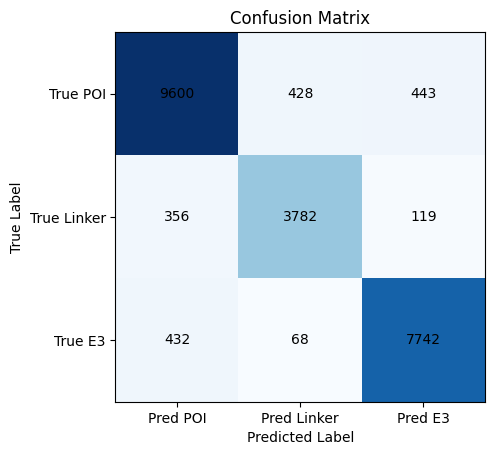

Sum of rows are sum of the number of nodes in the true substructure. 
Example: 7 True L & Pred Linker, means that the model correctly predicted 7 linker nodes. 
         3 True Linker & Pred E3, means that 3 nodes that are actually a part of the linker were predicted as E3 nodes


In [20]:

# Convert the matrix to a NumPy array for better handling
confusion_matrix_np = np.array(Confusion3Matrix_sum) 

# Create the heatmap
plt.imshow(confusion_matrix_np, cmap='Blues', interpolation='nearest')

# Add color bar
#plt.colorbar()

# Annotate the heatmap with text
for i in range(confusion_matrix_np.shape[0]):
    for j in range(confusion_matrix_np.shape[1]):
        text = plt.text(j, i, confusion_matrix_np[i, j], ha="center", va="center", color="black")

Correct_predictions = sum(np.diag(confusion_matrix_np))
total_predictions = np.sum(confusion_matrix_np)
confirm_validation_accuracy = Correct_predictions/total_predictions
print(f'Confusion matrix reproduces validation accuracy: {val_accuracy == confirm_validation_accuracy}')

# Adding labels for clarity
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Add x and y ticks (optional, for better clarity)
plt.xticks(range(len(confusion_matrix_np)), ['Pred POI', 'Pred Linker', 'Pred E3'])
plt.yticks(range(len(confusion_matrix_np)), ['True POI', 'True Linker', 'True E3'])

plt.show()
print("Sum of rows are sum of the number of nodes in the true substructure. \nExample: 7 True L & Pred Linker, means that the model correctly predicted 7 linker nodes. \n         3 True Linker & Pred E3, means that 3 nodes that are actually a part of the linker were predicted as E3 nodes")

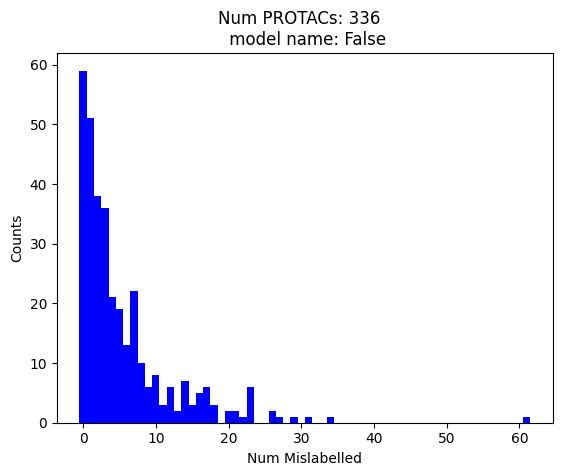

In [21]:
#Bar plot for Num nodes mislabelled nodes for whole PROTAC.
plt.bar(num_mislabelled.keys(), num_mislabelled.values(), 1, color='b')

plt.title(f'Num PROTACs: {len(chosen_dataset)}  \n model name: {model_name}')
plt.xlabel('Num Mislabelled')
plt.ylabel('Counts')
plt.show()



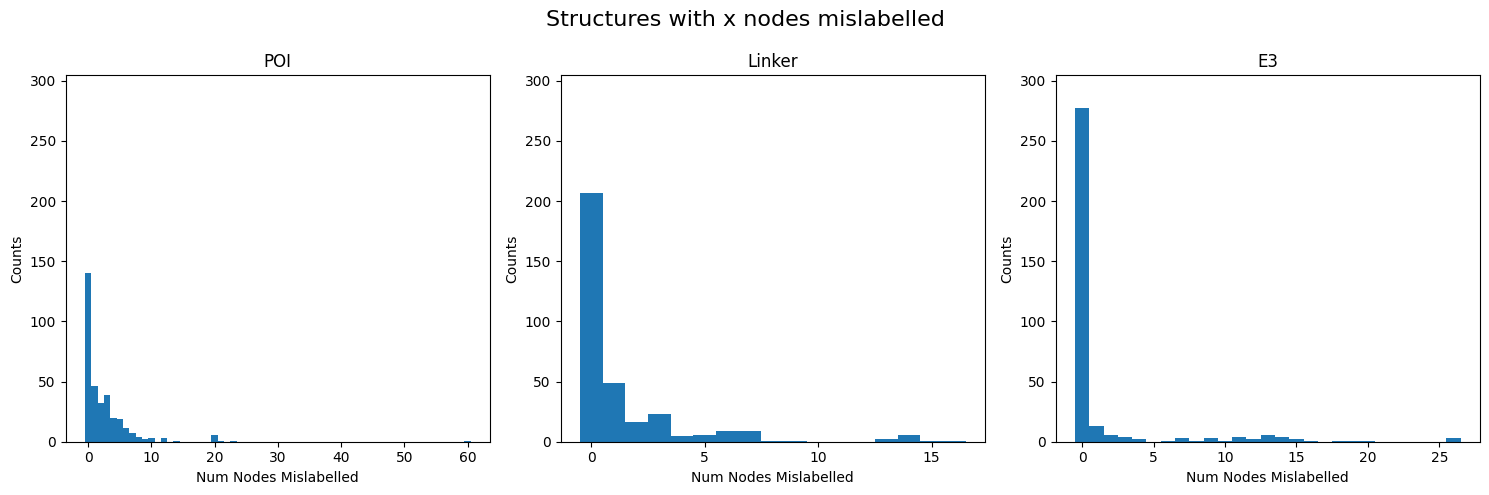

In [22]:
fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed for the bar plots

fig_bar, axes_bar = plt.subplots(1, 3, figsize=(fig_width, fig_height))
fig_bar.suptitle("Structures with x nodes mislabelled", fontsize=16)
substructure_str = ['POI', 'Linker', 'E3']

# Assuming you have separate num_mislabelled dictionaries for each substructure
num_mislabelled_dicts = [num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]

# Find the maximum y-value (count) across all substructures
max_y_val = 0
for num_mislabelled_struct in num_mislabelled_dicts:
    max_y_val = max(max_y_val, max(num_mislabelled_struct.values(), default=0))
max_y_val=max_y_val*1.1

for class_label, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    axes_bar[class_label].bar(num_mislabelled_struct.keys(), num_mislabelled_struct.values(), 1)
    axes_bar[class_label].set_title(f'{substructure_str[class_label]}')
    axes_bar[class_label].set_xlabel('Num Nodes Mislabelled')
    axes_bar[class_label].set_ylabel('Counts')
    
    # Set the same y-axis limits
    axes_bar[class_label].set_ylim(0, max_y_val)

    # Set the x-axis ticks based on the current subplot's data
    max_mislabeled = max(num_mislabelled_struct.keys(), default=0)
    step_size = 5 if max_mislabeled <= 30 else 10
    axes_bar[class_label].set_xticks(range(0, max_mislabeled + 1, step_size))

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust for the super title
plt.show()




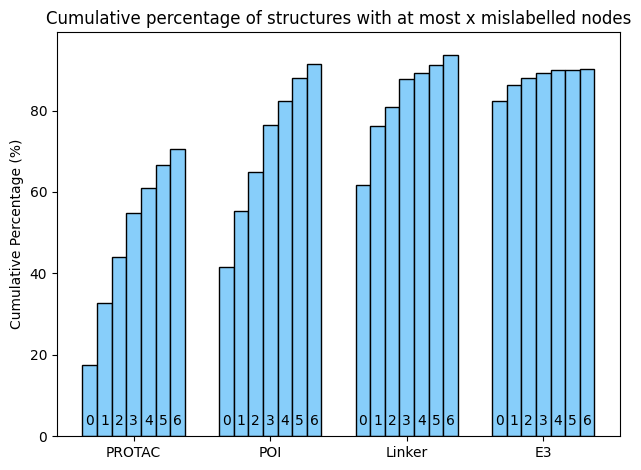

In [23]:

num_mislabelled_table_limit = 6
substructure_str = ['PROTAC', 'POI', 'Linker', 'E3']
cumulative_percentages = {sub: [0] * (num_mislabelled_table_limit + 1) for sub in substructure_str}

num_mislabelled_dicts = [num_mislabelled, num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]


# Variable for adjusting the height of the numbers
number_y_position = 2  # Adjust this value to change the vertical position of the numbers

# Data preparation
for sub_index, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    cumulative_prop = 0
    for i in range(num_mislabelled_table_limit + 1):
        if i in num_mislabelled_struct:
            current_prop = num_mislabelled_struct[i] / len(chosen_dataset)
        else:
            current_prop = 0
        cumulative_prop += current_prop
        cumulative_percentages[substructure_str[sub_index]][i] = cumulative_prop * 100

# Plotting
fig, ax = plt.subplots()
bar_width = 0.15  # Width of each bar
spacing = 0.05  # Spacing between groups
default_color = 'lightskyblue'  # Light blue color for the bars

for i in range(num_mislabelled_table_limit + 1):
    for sub_index, sub in enumerate(substructure_str):
        # Calculate the x position for each bar within the group
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.bar(x_pos, cumulative_percentages[sub][i], bar_width, color=default_color, edgecolor='black')

# Adding numbering below each bar
for sub_index, sub in enumerate(substructure_str):
    for i in range(num_mislabelled_table_limit + 1):
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.text(x_pos, number_y_position, str(i), ha='center', va='bottom')

# Labels and Ticks
ax.set_ylabel('Cumulative Percentage (%)')
ax.set_title('Cumulative percentage of structures with at most x mislabelled nodes')
ax.set_xticks([(num_mislabelled_table_limit + 1) * (bar_width + spacing) * sub_index + (num_mislabelled_table_limit / 2) * bar_width for sub_index in range(len(substructure_str))])
ax.set_xticklabels(substructure_str)
ax.set_ylim([0, max(cumulative_percentages[sub]) * 1.1])  # Adjust y-axis to fit the text

plt.tight_layout()
plt.show()



Num PROTACs in validation set: 336


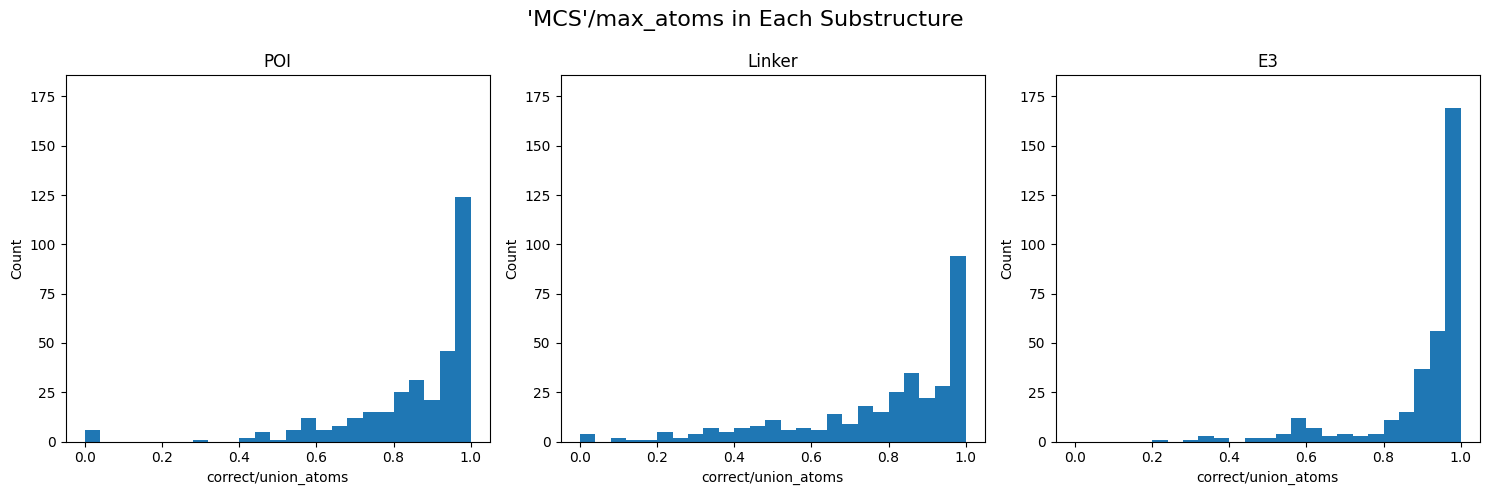

In [24]:
print(f'Num PROTACs in validation set: {len(POI_MCS_maxatoms_list)}')

fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed to make subplots square

fig_hist_MCS, axes_hist_MCS = plt.subplots(1, 3, figsize=(fig_width, fig_height))

# Use fig_hist_MCS for setting the super title
fig_hist_MCS.suptitle("'MCS'/max_atoms in Each Substructure", fontsize=16)

substructure_str = ['POI', 'Linker', 'E3']
max_y_val = 0  # Variable to store the maximum y-value across all histograms

# Calculate the maximum y-value without plotting
for X_MCS_maxatoms_list in [POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]:
    binwidth = 1/25
    bin_setting = np.arange(min(X_MCS_maxatoms_list), max(X_MCS_maxatoms_list) + binwidth, binwidth)
    counts, _ = np.histogram(X_MCS_maxatoms_list, bins=bin_setting)
    max_y_val = max(max_y_val, max(counts))*1.1

# Now plot and set the same y-axis limits
for class_label, X_MCS_maxatoms_list in enumerate([POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]):
    binwidth = 1/25
    bin_setting = np.arange(0, 1 + binwidth, binwidth)

    axes_hist_MCS[class_label].hist(x=X_MCS_maxatoms_list, bins=bin_setting)
    axes_hist_MCS[class_label].set_ylim(0, max_y_val)  # Set the same y-axis limits
    axes_hist_MCS[class_label].set_xlabel('correct/union_atoms')
    axes_hist_MCS[class_label].set_ylabel('Count')
    axes_hist_MCS[class_label].set_title(f'{substructure_str[class_label]}')

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the top padding to make room for the super title
plt.show()


In [25]:
"""def assign_pos_to_graph(smile, G):
    mol = Chem.MolFromSmiles(smile)
    AllChem.Compute2DCoords(mol)
    # Assign 2D coordinates to nodes
    conf = mol.GetConformer()
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        G.nodes[atom.GetIdx()]['pos'] = (pos.x, pos.y)
    pos = nx.get_node_attributes(G, 'pos')
    return G, pos

graph2 = chosen_dataset[idx].G
smile = chosen_dataset[idx].smiles

G, pos = assign_pos_to_graph(smile, graph2)
print(nx.get_node_attributes(graph2, 'pos'))
#print(graph.nodes)
#print(G)"""


{0: (-4.390675762681171, -0.3147440835318971), 1: (-3.3753755172474733, -1.4189023202091724), 2: (-1.9114963117702728, -1.0917056335336506), 3: (-1.446630631877915, -2.517854258207186), 4: (-0.7202652785567157, -3.830254110955795), 5: (-1.9576770666770476, -4.6780819629522), 6: (0.24134701179782747, -4.981471641676678), 7: (-0.8132506572949527, -6.048159860578561), 8: (-0.41677039635473534, -7.494812342235707), 9: (-2.2643285873279506, -5.6681955978233), 10: (-3.3189262564207307, -6.734883816725185), 11: (-2.660808848268168, -4.2215431161661545), 12: (-4.111886778301166, -3.8415788534108932), 13: (-4.508367039241382, -2.3949263717537477), 14: (-5.959444969274379, -2.014962108998487), 15: (-6.355925230214597, -0.5683096273413417), 16: (-7.807003160247595, -0.18834536458608042), 17: (-8.203483421187812, 1.2583071170710647), 18: (-9.65456135122081, 1.6382713798263262), 19: (-10.70915902031359, 0.5715831609244417), 20: (-10.051041612161027, 3.0849238614834715), 21: (-11.502119542194025, 3.

In [34]:
# number of valid smiles
# Convert G -> mol -> SMILES

#TODO I should store pos from the generated graph, likewise, I should store atom identity for simple downstream processing.

def adjust_bond_types(mol):
    # Iterate over all bonds
    for bond in mol.GetBonds():
        if bond.GetBondType() == Chem.rdchem.BondType.AROMATIC:
            # Check if both atoms connected by the bond are in a ring
            if not (mol.GetAtomWithIdx(bond.GetBeginAtomIdx()).IsInRing() and
                    mol.GetAtomWithIdx(bond.GetEndAtomIdx()).IsInRing()):
                # Adjust the bond type (e.g., to SINGLE or DOUBLE)
                bond.SetBondType(Chem.rdchem.BondType.SINGLE)  # or DOUBLE, depending on context


def adjust_bond_types_for_kekulization(mol):
    # Iterate over all bonds
    for bond in mol.GetBonds():
        # Check for aromatic bonds
        if bond.GetBondType() == Chem.rdchem.BondType.AROMATIC:
            # Get atoms connected by the bond
            atom1 = mol.GetAtomWithIdx(bond.GetBeginAtomIdx())
            atom2 = mol.GetAtomWithIdx(bond.GetEndAtomIdx())

            # Check if both atoms are in a ring
            if not (atom1.IsInRing() and atom2.IsInRing()):
                # Adjust the bond type (e.g., to SINGLE or DOUBLE)
                bond.SetBondType(Chem.rdchem.BondType.SINGLE)  # or DOUBLE


invalid_smiles_counter_substructures = [0, 0, 0]
valid_smiles_counter_substructures = [0, 0, 0]
valid_protac_substructure_split_counter = [0, 0]  #first element is the counter, second element is a temporary variable which counts 0, 1, 2, for each substructure, and when it becomes 2 it adds 1 to the first elements and resets itself.

for idx in range(len(chosen_dataset)):#[204, 317, 318]: #range(len(chosen_dataset)):
    #idx=5
    substructure_smiles = chosen_dataset[idx].substructure_smiles
    protac_smile = chosen_dataset[idx].smiles
    graph = chosen_dataset[idx].G
    #vizualize_protac_From_Smile(protac_smile, node_size=80)


        
    chosen_datapoint=chosen_dataset[idx]
    protac_smile = chosen_datapoint.smiles
    substructure_smiles = chosen_datapoint.substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    G_pred=chosen_datapoint.G

    pt = GetPeriodicTable()
    atom_types = ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I']  # Common atom types, add more as needed

    # One-hot encoding of atom types
    def atom_features(atom):
        return [1 if atom.GetSymbol() == symbol else 0 for symbol in atom_types]

    # Create a data object
    molecule_data = Data(x=chosen_datapoint.x, edge_index=chosen_datapoint.edge_index, edge_attr=chosen_datapoint.edge_attr)

    # Make predictions
    class_predictions, probabilities = predict(model, molecule_data)
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    #print('index: ', idx)
    #print('protac_smile', protac_smile)
    # Combine and display the two figures
    #combine_two_figures(fig_gt, fig_pred)


    #class_label = 0
    #node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
    #subgraph_substructure = graph.subgraph(node_indices_substructure)
    #is_graph_connected = nx.is_connected(subgraph_substructure)
    #print("Graph is connected:", is_graph_connected)
    #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)

    #vizualize_protac_From_Graph(graph, node_size=80)

    substruct_str = ['POI', 'Linker', 'E3']
    #print("PROTAC:")
    #vizualize_protac_From_Graph(graph, node_size=80)
    valid_protac_substructure_split_counter[1] = 0
    for class_label in [0, 1, 2]:
        node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
        subgraph_substructure = graph.subgraph(node_indices_substructure)
        # Create a mapping from old indices (from the original graph) to new indices (for the RDKit molecule)
        index_mapping = {old_index: new_index for new_index, old_index in enumerate(subgraph_substructure.nodes())}
        if len(subgraph_substructure) > 0:
            is_graph_connected = nx.is_connected(subgraph_substructure)
        else:
            is_graph_connected = None
        #print(f'Predicted {substruct_str[class_label]} is connected: {is_graph_connected}')
        #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)
        #print(f'subgraph_substructure, {subgraph_substructure}' )
        #print(f'graph: {graph}')

        #print("Graph is connected:", is_graph_connected)
        try: 
            pass
            #mol_substructure = graph_to_mol(subgraph_substructure)
            #reassembled_protac_smile = Chem.MolToSmiles(mol_substructure)
        except RuntimeError:
            pass
            #print("invalid smile")
        if is_graph_connected is True:
            new_mol = Chem.RWMol()

            # Add atoms to the molecule
            for node, attr in subgraph_substructure.nodes(data=True):
                atom = Chem.Atom(attr['atomic_num'])
                
                new_mol.AddAtom(atom)

            # Add bonds to the molecule
            for start, end, attr in subgraph_substructure.edges(data=True):
                # Map the original node indices to the new indices
                new_start = index_mapping[start]
                new_end = index_mapping[end]

                bond_type = attr['bond_type']
                new_mol.AddBond(new_start, new_end, bond_type)

            adjust_bond_types(new_mol)
            adjust_bond_types_for_kekulization(new_mol)

            # Convert to a standard RDKit molecule and return
            mol_substructure = new_mol.GetMol()
            reassembled_substructure_smile = Chem.MolToSmiles(mol_substructure)
            #print(f'reassembled_substructure_smile ({substruct_str[class_label]}): {reassembled_substructure_smile}')


            
            if reassembled_substructure_smile is None:
                invalid_smiles_counter_substructures[class_label] += 1
                print("is none")
            elif isinstance(reassembled_substructure_smile, str): 
                valid_smiles_counter_substructures[class_label] += 1
                valid_protac_substructure_split_counter[1] += 1
            else:
                print("is else")
                print(type(reassembled_substructure_smile))
                print(reassembled_substructure_smile)
                print(invalid_smiles_counter_substructures)
        else:
            invalid_smiles_counter_substructures[class_label] += 1

        #print(f'Pre: {valid_protac_substructure_split_counter}')
        if valid_protac_substructure_split_counter[1] == 3:
            valid_protac_substructure_split_counter[0] += 1
            valid_protac_substructure_split_counter[1] = 0
        #print(f'post: {valid_protac_substructure_split_counter}')


                
            
            #"""try:
            #    Chem.Kekulize(mol, clearAromaticFlags=True)
            #    Chem.SanitizeMol(mol)
            #except Chem.KekulizeException:
             #   print("Kekulization issue: Can't kekulize mol.")
            #except Chem.AtomKekulizeException:
             #   print("Sanitization issue: non-ring atom marked aromatic")"""


            #reassembled_protac_smile = Chem.MolToSmiles(mol)
    #print("--------------------------------------------------------------------------------------------------------------------------------")
    

print(substruct_str, ":")
print(f'invalid_smiles_counter_substructures: {invalid_smiles_counter_substructures}')
print(f'valid_smiles_counter_substructures: {valid_smiles_counter_substructures}')
print(f'valid_protac_substructure_split_counter: {valid_protac_substructure_split_counter[0]}')
print(f'chosen_dataset {chosen_dataset}')
invalid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in invalid_smiles_counter_substructures]
valid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in valid_smiles_counter_substructures]
valid_protac_substructure_split_percentage = round(100*valid_protac_substructure_split_counter[0]/ len(chosen_dataset),1)
print(f'invalid_smiles_percentage_substructures: {invalid_smiles_percentage_substructures}')
print(f'valid_smiles_percentage_substructures: {valid_smiles_percentage_substructures}')
print(f'valid_protac_substructure_split_percentage: {valid_protac_substructure_split_percentage}')



Pre: [0, 1]
post: [0, 1]
Pre: [0, 2]
post: [0, 2]
Pre: [0, 3]
post: [1, 0]
Pre: [1, 0]
post: [1, 0]
Pre: [1, 1]
post: [1, 1]
Pre: [1, 1]
post: [1, 1]
Pre: [1, 1]
post: [1, 1]
Pre: [1, 2]
post: [1, 2]
Pre: [1, 2]
post: [1, 2]
Pre: [1, 1]
post: [1, 1]
Pre: [1, 2]
post: [1, 2]
Pre: [1, 2]
post: [1, 2]
Pre: [1, 1]
post: [1, 1]
Pre: [1, 2]
post: [1, 2]
Pre: [1, 3]
post: [2, 0]
Pre: [2, 1]
post: [2, 1]
Pre: [2, 2]
post: [2, 2]


KeyboardInterrupt: 

In [ ]:
print(substruct_str, ":")
invalid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in invalid_smiles_counter_substructures]
valid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in valid_smiles_counter_substructures]
print(f'invalid_smiles_percentage_substructures: {invalid_smiles_percentage_substructures}')
print(f'valid_smiles_percentage_substructures: {valid_smiles_percentage_substructures}')

['POI', 'Linker', 'E3'] :
invalid_smiles_percentage_substructures: [42.3, 26.5, 29.2]
valid_smiles_percentage_substructures: [57.7, 73.5, 70.8]
